In [1]:
import pandas as pd
import seaborn as sns

- We will use 4 datasets in this notebook, to show various EDA techniques:
  - tips (restaurant tips data)
  - iris (flower measurements)
  - penguins (penguin species data)
  - flights (airline passenger data)

In [2]:
tips = sns.load_dataset('tips')

In [4]:
tips.sample(5)

,total_bill,tip,sex,smoker,day,time,size
56,38.01,3.00,Male,Yes,Sat,Dinner,4
222,8.58,1.92,Male,Yes,Fri,Lunch,1
196,10.34,2.00,Male,Yes,Thur,Lunch,2
100,11.35,2.50,Female,Yes,Fri,Dinner,2
2,21.01,3.50,Male,No,Sun,Dinner,3


In [8]:
titanic = pd.read_csv('../../train.csv')

In [9]:
flights = sns.load_dataset('flights')

In [10]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [11]:
iris = sns.load_dataset('iris')

In [12]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


- Lets start with bivariate analysis, jaha jaha vhi multivariate analysis ki jarurat padegi wo hum kr lenge.

- When you want to analyse 2 different columns,the question you ask is what is the data type of both the columns.
- There are 3 possibilities:
  - Both columns are numerical
  - Both columns are categorical
  - One column is numerical and other is categorical

- So inhi 3 combinations k liye hum alag alag plot padhenge

## 1. Scatterplot (Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

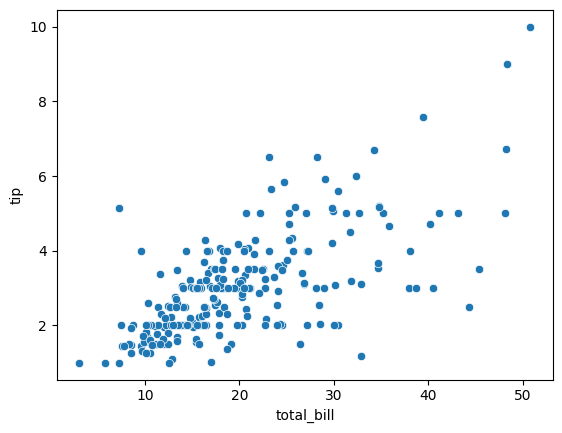

In [15]:
# we are visualising the total bill vs tip amount in the tips dataset
sns.scatterplot(tips, x='total_bill', y='tip')
# we can see almost linear relationship between total bill and tip amount, which makes sense as well

- Now lets do the multivariate analysis using in the same dataset

<Axes: xlabel='total_bill', ylabel='tip'>

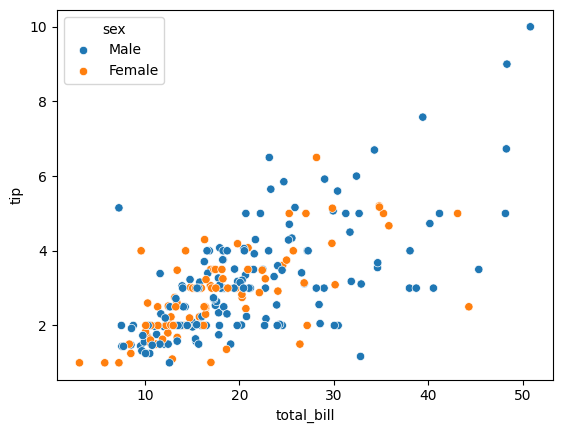

In [17]:
# In the above plot, I want to see which is male or female
sns.scatterplot(tips, x='total_bill', y='tip', hue='sex')
# So here we did analysis of 3 variables/columns

<Axes: xlabel='total_bill', ylabel='tip'>

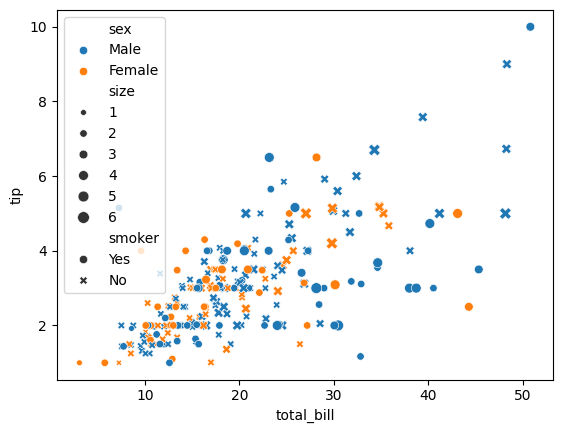

In [21]:
# Now I want to see smoker or not also and size of the group also
sns.scatterplot(tips, x='total_bill', y='tip', hue='sex', style='smoker', size='size')
# So here we did analysis of 5 variables/columns

## 2. Bar Plot (Numerical - Categorical)

- **We put categorical variable on x-axis and numerical variable on y-axis**

In [22]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Age'>

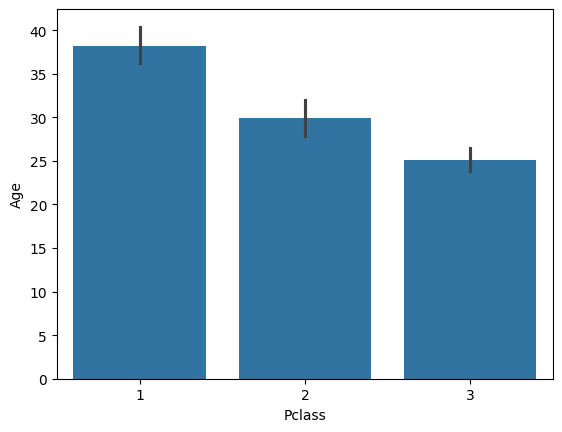

In [24]:
# We want to see whats the average age in each Passenger class(Pclass)
sns.barplot(titanic, x='Pclass', y='Age')
# We can see that higher the class, higher is the average age of passengers in that class
# The black line on top of each bar is the confidence interval, which tells us how sure we are about the average value shown by the bar.
# Shorter the line, more sure we are about the average value.

<Axes: xlabel='Pclass', ylabel='Fare'>

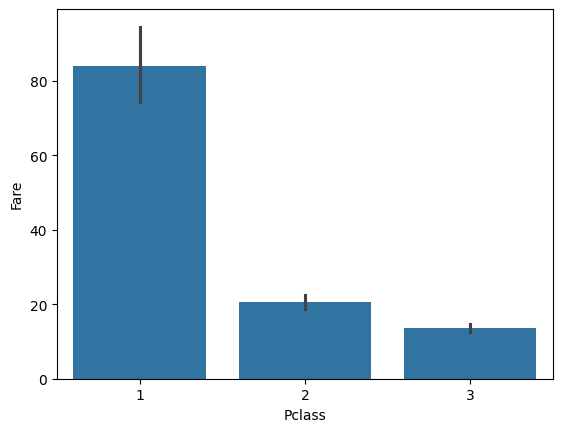

In [25]:
# bivararite analysis of fare and Pclass
sns.barplot(titanic, x='Pclass', y='Fare')

<Axes: xlabel='Pclass', ylabel='Fare'>

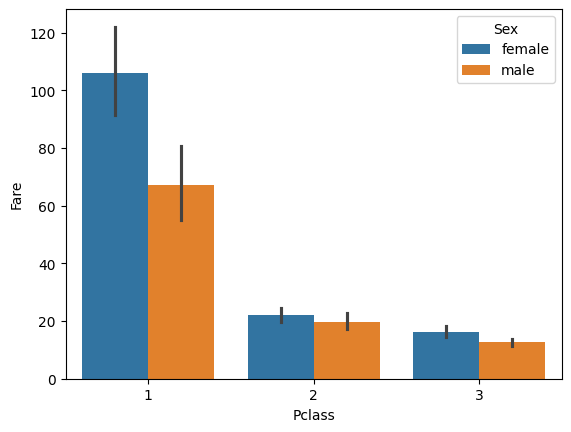

In [26]:
# Now lets do the multivariate analysis using in the same dataset
sns.barplot(titanic, x='Pclass', y='Fare', hue='Sex')

- It means that average fare paid be females in every class is higher than males.

## 3. Box Plot (Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

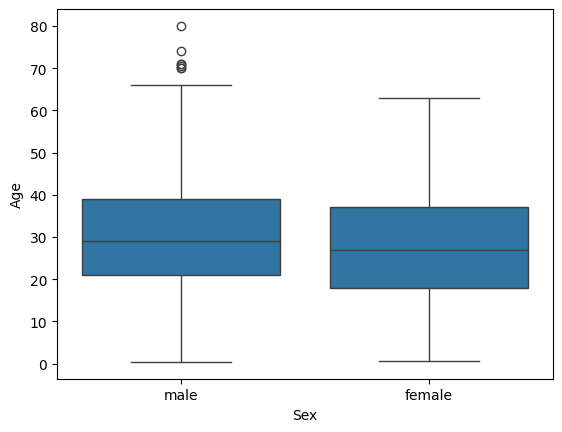

In [28]:
#let's visualise box plot of age for male and female separately
sns.boxplot(titanic, x='Sex', y='Age')

<Axes: xlabel='Sex', ylabel='Age'>

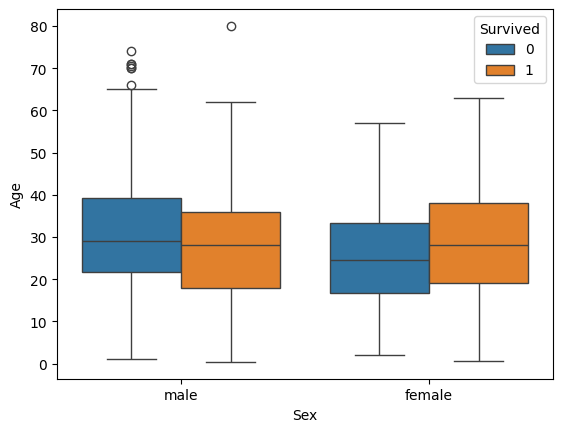

In [29]:
# Now lets do the multivariate analysis using in the same dataset
sns.boxplot(titanic, x='Sex', y='Age', hue='Survived')

## 4. Distplot (Numerical - Categorical)

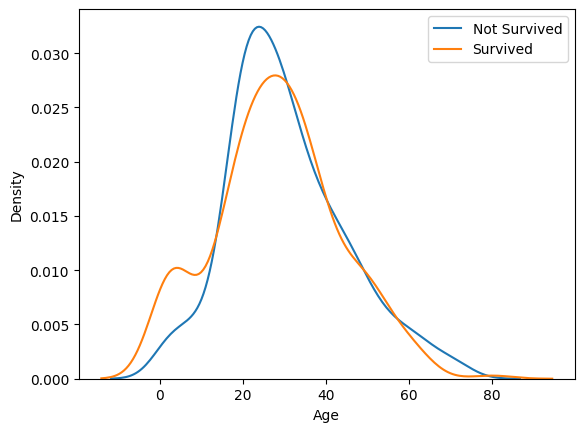

In [42]:
# sns.distplot(titanic[titanic['Survived']==0]['Age'],hist=False)
# sns.distplot(titanic[titanic['Survived']==1]['Age'],hist=False)

import matplotlib.pyplot as plt

# We are visualising age(numerical variable) distribution for survived and not survived(categorical variable)
sns.kdeplot(titanic.loc[titanic['Survived']==0, 'Age'].dropna(), label='Not Survived')
sns.kdeplot(titanic.loc[titanic['Survived']==1, 'Age'].dropna(), label='Survived')
plt.xlabel('Age')
plt.legend()

- You can see that for age smaller than 18, probability of survival is higher.

## 5. HeatMap (Categorical - Categorical)

In [43]:
titanic.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
191,192,0,2,"Carbines, Mr. William",male,19.0,0,0,28424,13.000,NaN,S
210,211,0,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.050,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.550,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.125,NaN,Q
617,618,0,3,"Lobb, Mrs. William Arthur (Cordelia K Stanlick)",female,26.0,1,0,A/5. 3336,16.100,NaN,S


- We want to see in each passenger class, how many survived and how many didnt survive

In [37]:
pd.crosstab(titanic['Pclass'], titanic['Survived'])
# from the below table you can see that in Pclass 1, 136 survived and 80 didnt survive and so on

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

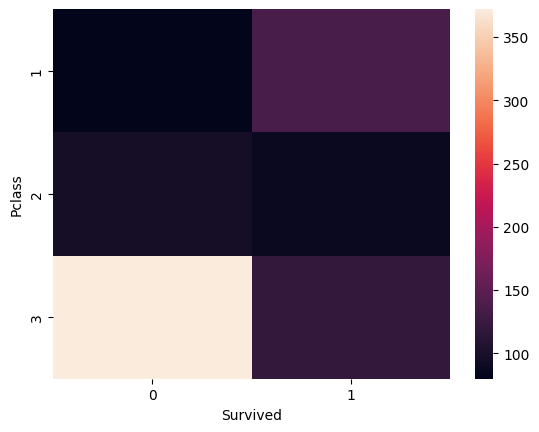

In [36]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived']))

- From the above heatmap, u can see that Pclass 3 has lightest color for not survived, meaning not survived count is highest in Pclass 3.
- But Pclasss 3 also has highest count overall, so to get better idea we will see percentage of survived passengers in each class
- So we use groupby function to get percentage of survived passengers in each class

In [40]:
titanic.groupby('Pclass')['Survived'].mean()*100
# since this is a series, we can directly plot it

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

<Axes: xlabel='Pclass'>

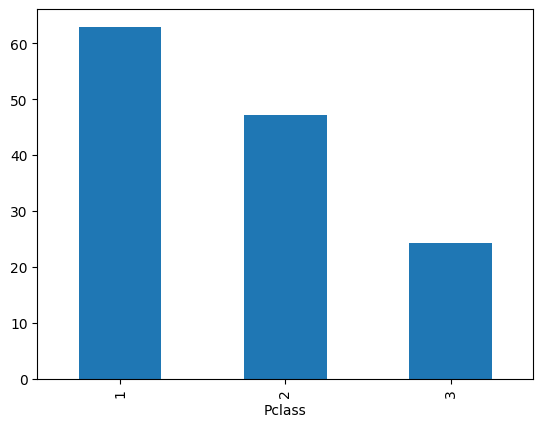

In [41]:
(titanic.groupby('Pclass')['Survived'].mean()*100) .plot(kind='bar')

## 6. ClusterMap (Categorical - Categorical)

### What is a Cluster Map?
- A **clustermap** = **heatmap + hierarchical clustering**
- Used to show **similarity patterns** in data

### What is a Dendrogram?
- A **tree diagram** showing how data points are **merged step-by-step**
- **Leaves (1–5)** → individual data points
- **Branches** → cluster formation
- **Height of merge** → distance / dissimilarity

### How to Read the Dendrogram
- Lower merge height → **more similar**
- Higher merge height → **less similar**
- Early merge = strong similarity (e.g., 1 & 2)
- Final merge = most dissimilar clusters

### What Does It Mean?
- Shows **hierarchical clustering**
- Clusters form based on **distance**
- Cutting the tree at a height gives number of clusters

### Relation Between Heatmap & Dendrogram
- **Dendrogram decides ordering**
- **Heatmap shows values using colors**
- Similar rows/columns appear **together as color blocks**

### One-Line Summary
- A clustermap visualizes **clusters and data values together**, using a dendrogram for structure and a heatmap for magnitude.


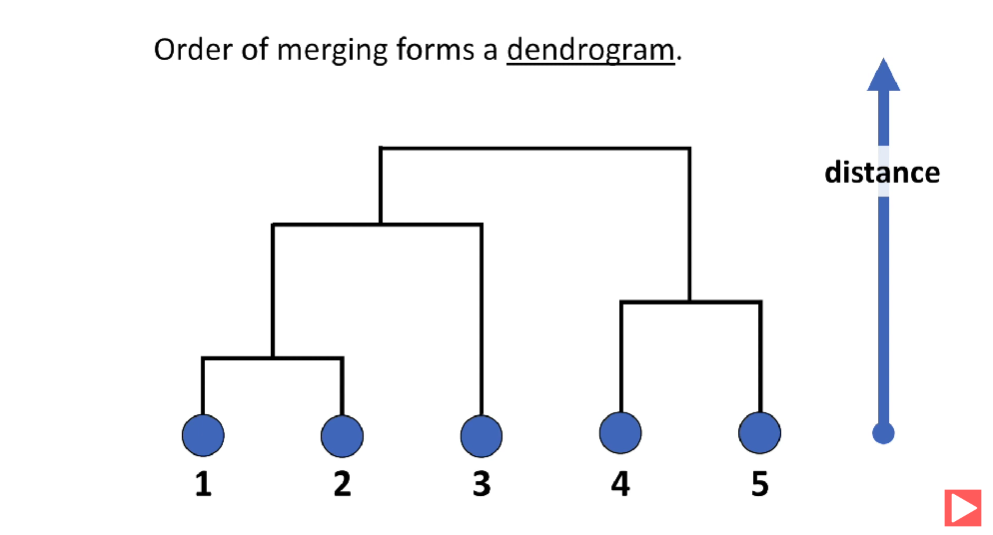

In [50]:
pd.crosstab(titanic['Pclass'], titanic['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


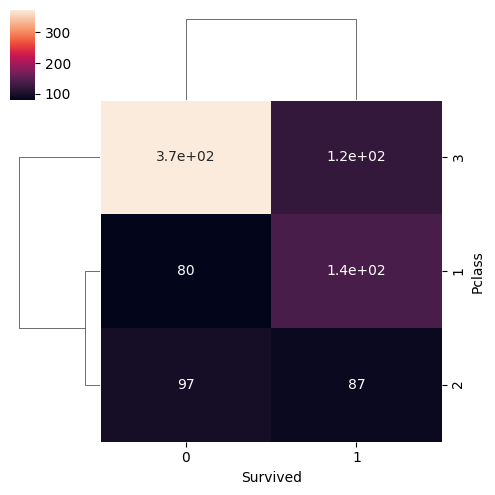

In [49]:
sns.clustermap(pd.crosstab(titanic['Pclass'],titanic['Survived']),figsize=(5,5),annot=True)

### Heatmap Observations
- **Pclass 3** shows **very high non-survivors (0)** and **low survivors (1)**
- **Pclass 1** shows **higher survivors than non-survivors**
- **Pclass 2** has **balanced but lower overall counts**

### Dendrogram Insights
- **Survived = 0 and 1** form distinct clusters → survival outcome strongly separates data
- **Pclass 2 and 3** are more similar to each other than to Pclass 1
- **Pclass 1** behaves distinctly → higher survival probability

### Cluster Interpretation
- **Lower passenger class → lower survival**
- **Higher passenger class → higher survival**
- Socio-economic status (Pclass) is strongly correlated with survival

### One-Line Conclusion
- The cluster map reveals that **Pclass is a strong determinant of survival**, with first-class passengers clustering with higher survival and third-class with higher mortality.

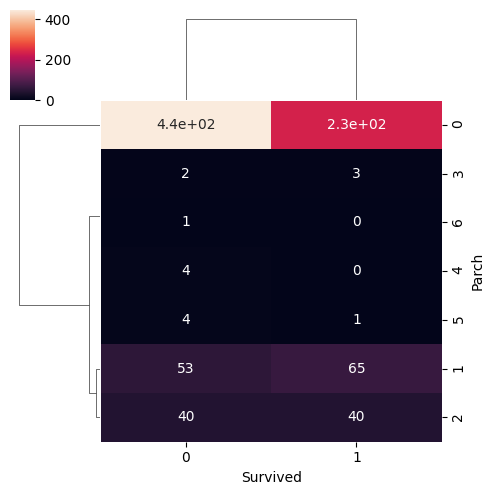

In [51]:
sns.clustermap(pd.crosstab(titanic['Parch'],titanic['Survived']), figsize=(5,5), annot=True)

## 7. Pairplot

- Pairplot is the collection of multiple scatter plots for numerical-numerical analysis.
- It is used to see the pairwise relationships between different numerical columns in the dataset.
- It automatically detects the numerical columns and plots scatter plots for each pair of numerical columns. 

In [52]:
iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
42,4.4,3.2,1.3,0.2,setosa
68,6.2,2.2,4.5,1.5,versicolor
19,5.1,3.8,1.5,0.3,setosa
28,5.2,3.4,1.4,0.2,setosa


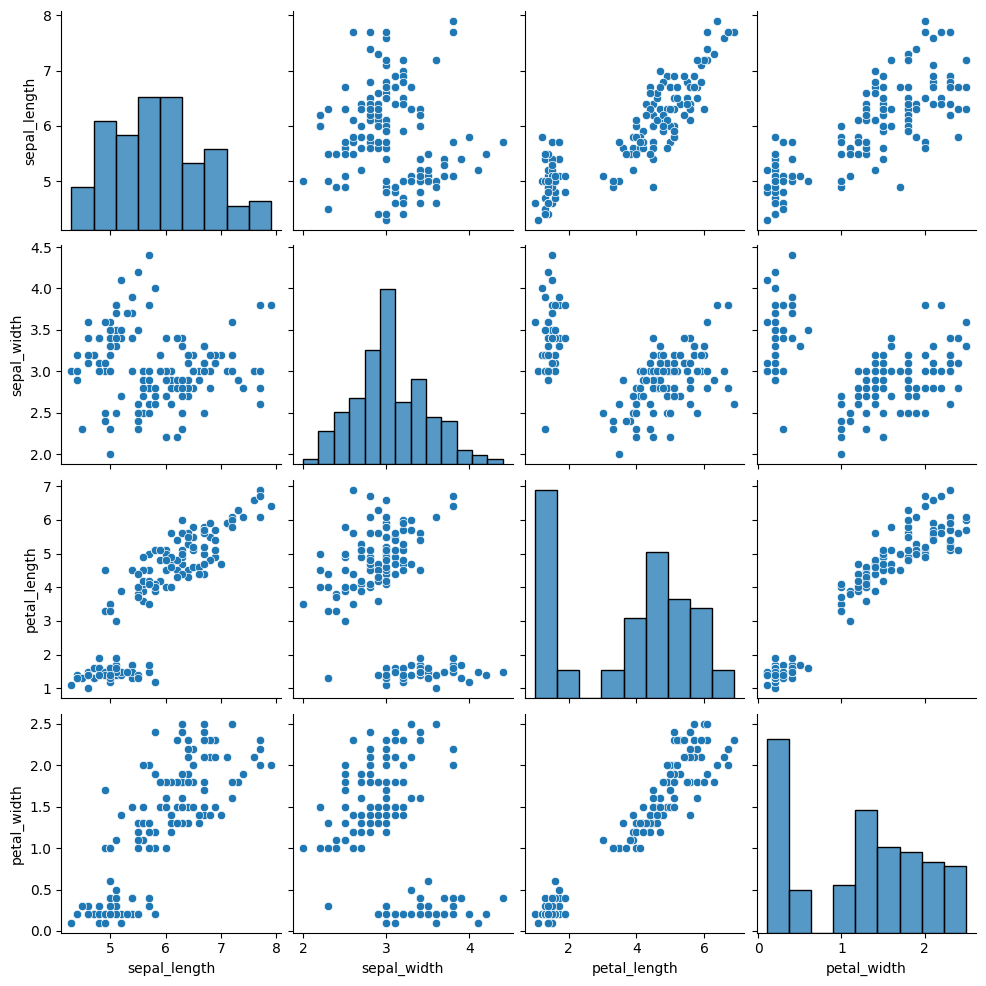

In [53]:
sns.pairplot(iris)

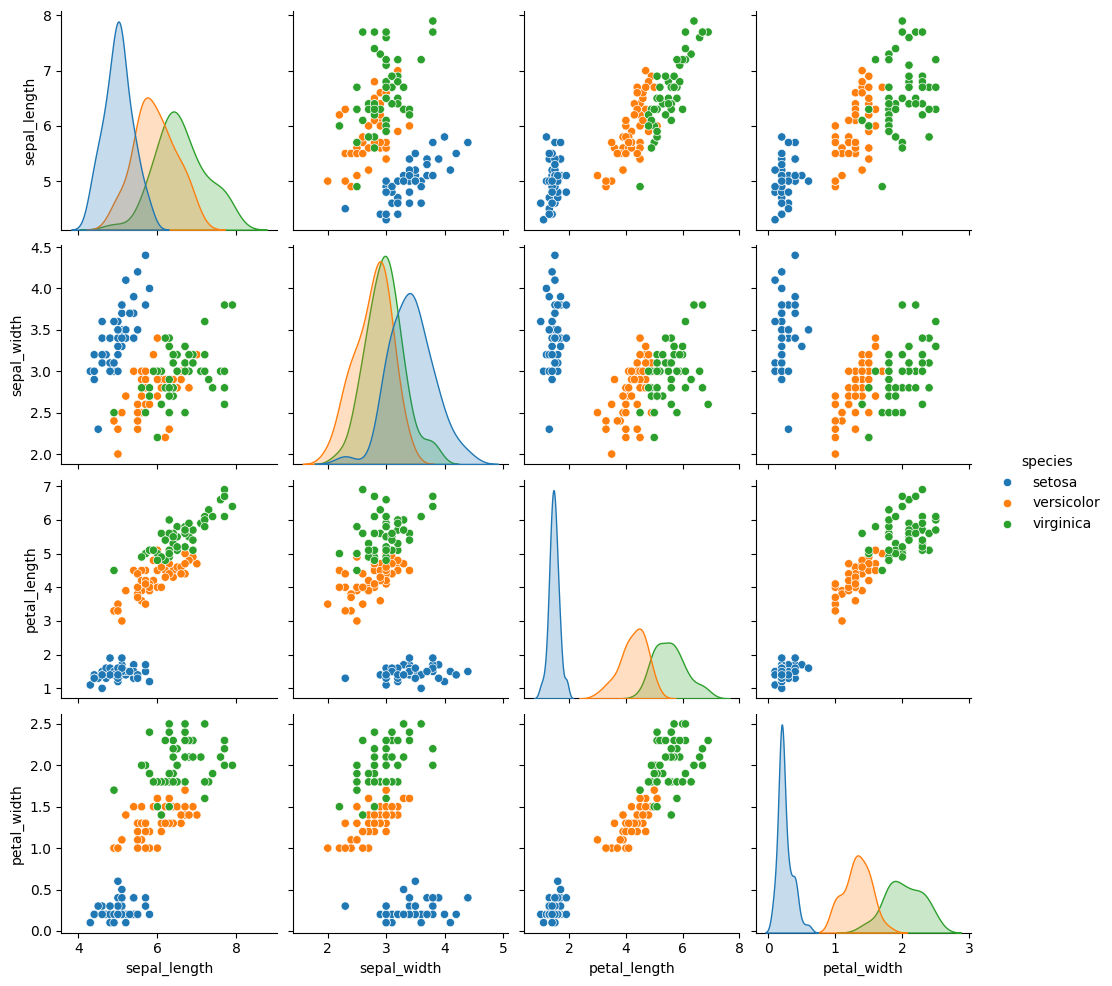

In [54]:
sns.pairplot(iris,hue='species')

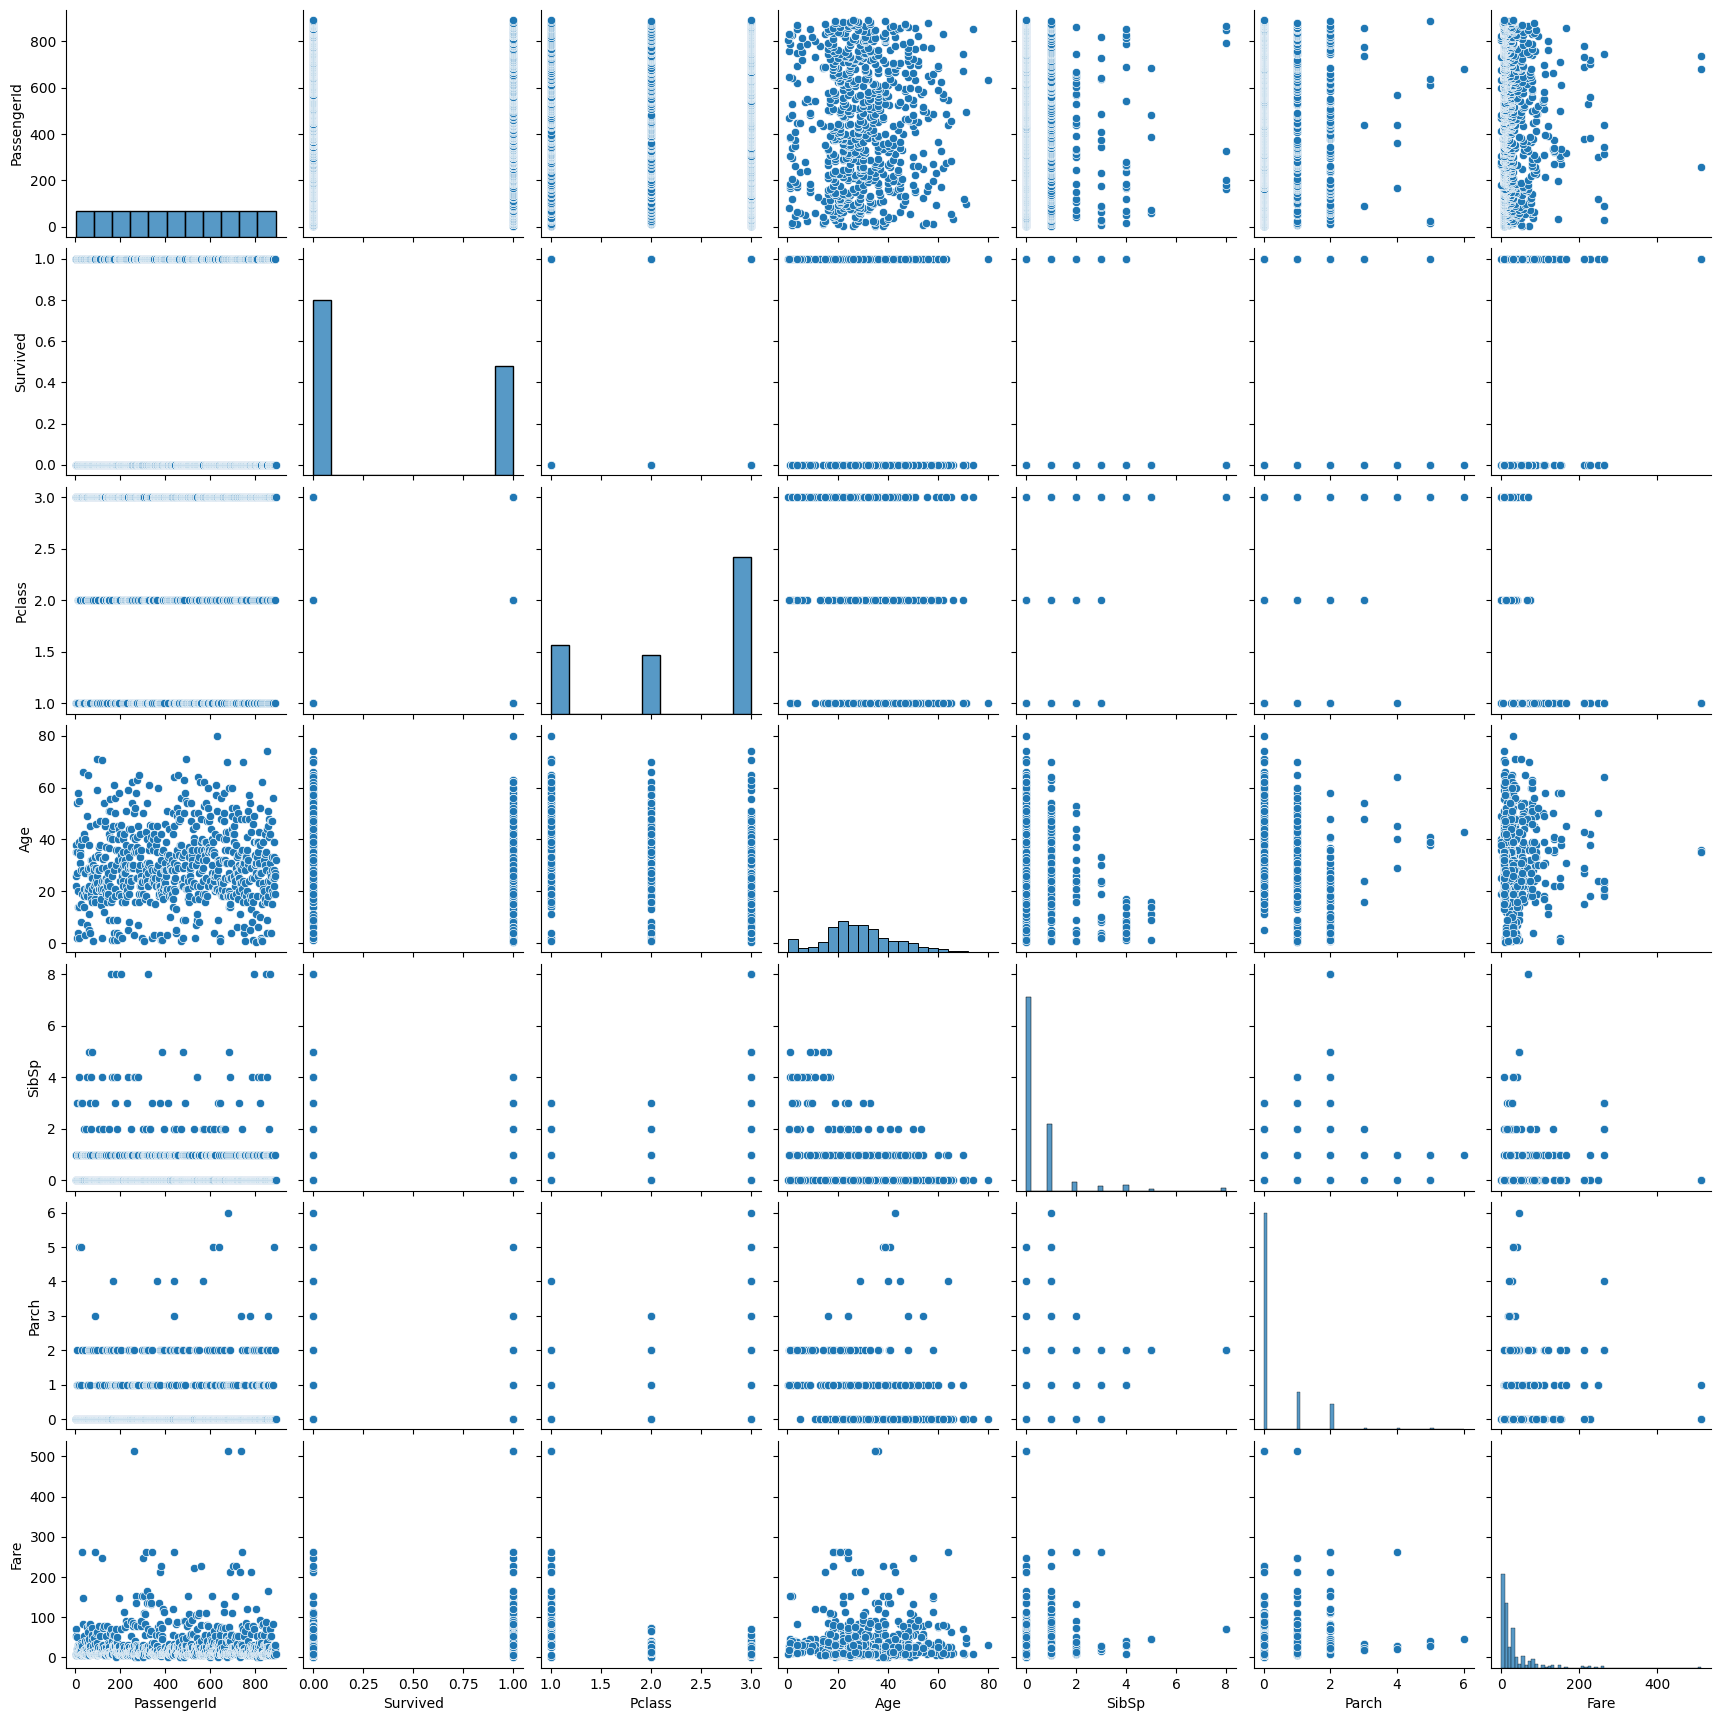

In [55]:
sns.pairplot(titanic)

### Interpretation of Titanic Pair Plot

- The pair plot shows **pairwise scatter plots** for numerical columns such as  
  **Age, Fare, SibSp, Parch, and Pclass**.
- Although **Pclass is stored as a numerical column**, it actually represents
  **categories (1st, 2nd, 3rd class)**.
- Hence, Pclass can be analyzed both as:
  - **Numerical** (for distance-based plots like pairplot)
  - **Categorical** (for barplots, countplots, etc.)

### How Pair Plot Helps in Decision
- If a variable forms **horizontal or vertical bands** in scatter plots  
  → treat it as **categorical** (e.g., Pclass, Survived).
- If two variables show a **continuous or linear trend**  
  → treat both as **numerical** (e.g., Age vs Fare).

### Key Insight
- Pair plots help decide whether a column should be treated as
  **numerical or categorical** by visually inspecting relationships.

### One-Line Conclusion
- Even if a column is numeric in form, **pair plots help determine its true analytical nature** based on observed patterns.
.

## 8. Lineplot (Numerical - Numerical)

- Its a special case of scatter plot, where we join all the points with lines
- It is used to see the trend of numerical variable over another numerical variable, usually time based (e.g., time series data,year,month).


In [56]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [58]:
#  we group by year and get the total number of passengers for each year
new = flights.groupby('year', as_index=False)['passengers'].sum()

In [59]:
new.head()

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700


<Axes: xlabel='year', ylabel='passengers'>

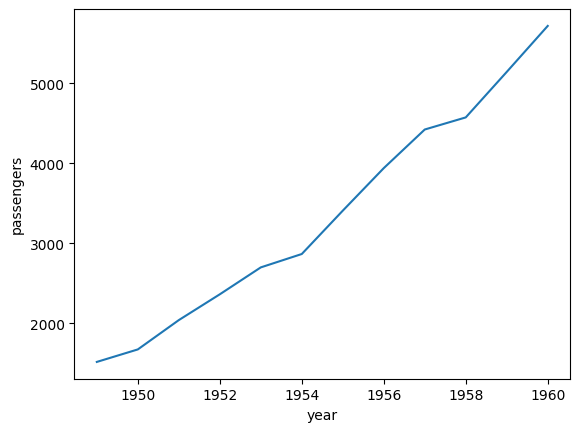

In [61]:
sns.lineplot(new, x='year', y='passengers')
# x-axis : year (time based quantity)
# y-axis : total number of passengers in that year

## -------------------------Done-------------------------

- Lets implement heatmap and clustermap using flights dataset

In [62]:
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [63]:
flights.pivot_table(index='month', columns='year', values='passengers')
# Above is the pivot table which we will use to plot heatmap and clustermap
# we need to do this because heatmap and clustermap need data in matrix form

C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_24268\3875736944.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(index='month', columns='year', values='passengers')


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


C:\Users\Kaushik Mandal\AppData\Local\Temp\ipykernel_24268\1868718285.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))


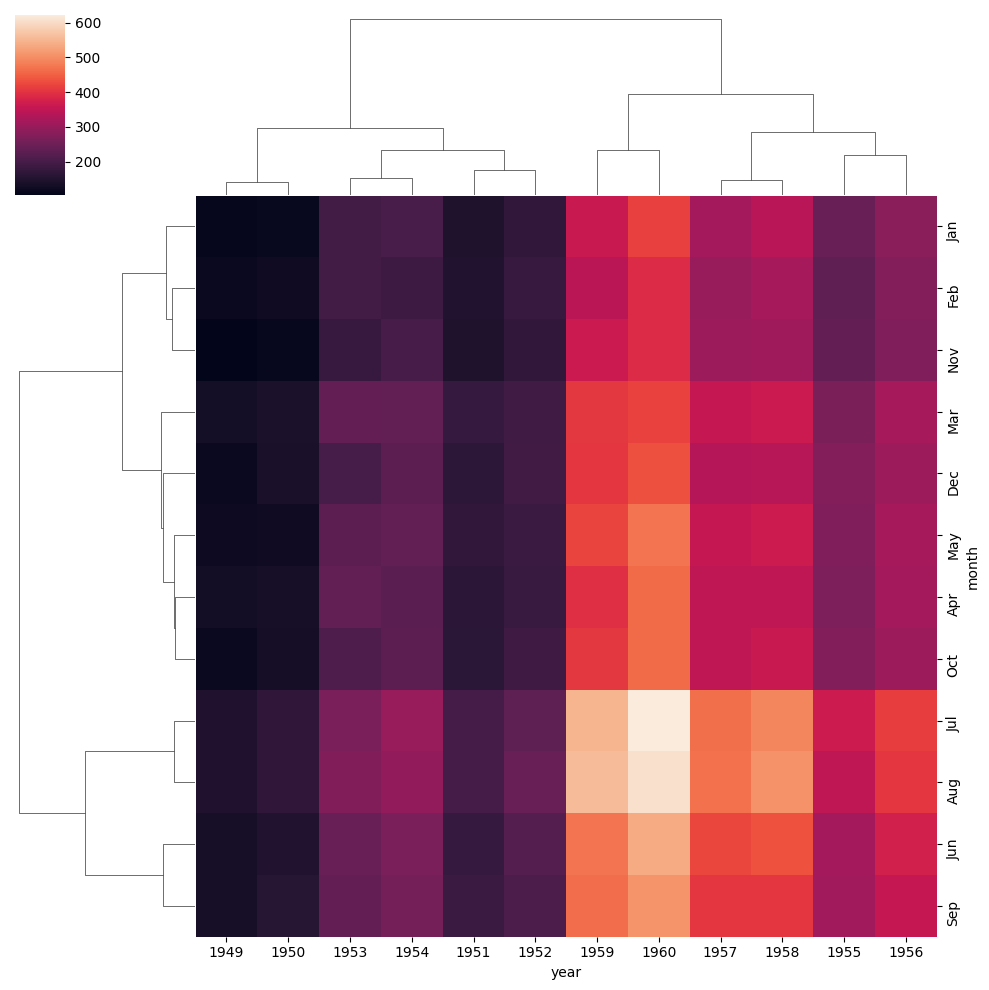

In [64]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))